# 不均衡データ対処手法 比較実験

## このノートブックの目的

不均衡データ（不正検知など）に対する7つのアプローチを、同じデータ・同じモデル・同じ評価指標で比較し、各手法の特性を体感する。

|#|手法|カテゴリ|
|:--:|:--|:--|
|1|NoResampling|ベースライン|
|2|RandomOverSampling|オーバーサンプリング|
|3|RandomUnderSampling|アンダーサンプリング|
|4|SMOTE|オーバーサンプリング|
|5|ADASYN|オーバーサンプリング|
|6|Combined (SMOTE + Under)|組み合わせ|
|7|ClassWeight|アルゴリズム側対処|

## アーキテクチャ概要

```
src/imbalance/
  ├── base.py        ← ImbalanceStrategy（抽象基底クラス）
  ├── strategies.py  ← 7つの具体実装（ConcreteStrategy）
  ├── factory.py     ← ImbalanceStrategyFactory（手法の生成と管理）
  └── __init__.py    ← 公開API

呼び出し側（このNotebook）はFactoryに文字列を渡すだけでよい:
  strategy = ImbalanceStrategyFactory.create('smote')
  result   = strategy.apply(X_train, y_train)
```

---

## ⚙️ セットアップ

In [5]:
# Standard
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

# 3rd party
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, f1_score
)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Custom
from src.imbalance import ImbalanceStrategyFactory
from data.generate_data import generate_fraud_dataset
from src.preprocess import add_features, split_and_scale


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
RANDOM_SEED = 42
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# カラーパレット（手法ごとに固定色を割り当て）
STRATEGY_COLORS = {
    'NoResampling（補正なし）':              '#888888',
    'RandomOverSampling（ランダム複製）':      '#4E79A7',
    'RandomUnderSampling（ランダム削除）':     '#F28E2B',
    'SMOTE（合成少数サンプル生成）':             '#59A14F',
    'ADASYN（適応的合成サンプリング）':           '#E15759',
    'Combined（SMOTE + UnderSampling）': '#B07AA1',
    'ClassWeight（クラス重み付け）':            '#76B7B2',
}

print('✅ セットアップ完了')
print('利用可能な戦略:', ImbalanceStrategyFactory.available_strategies())

✅ セットアップ完了
利用可能な戦略: ['none', 'over', 'under', 'smote', 'adasyn', 'combined', 'classweight']


## Step1 : データ準備

2種類のデータセットを用意して比較します。

- **Dataset A (プロジェクト用)** : 不正検知の擬似データ（不正率0.5%）
- **Dataset B (比較実験用)** : sklearn の make_classification（手法差が出やすい設定）

In [2]:
# Dataset A : プロジェクト擬似データ
print("--- Dataset A : 不正検知擬似データ ---")
df = generate_fraud_dataset(n_samples=50_000, fraud_rate=0.005, random_seed=RANDOM_SEED)
df = add_features(df)
X_train_A, X_test_A, y_train_A, y_test_A, _, feature_cols = split_and_scale(df)
print(f"特徴量数: {len(feature_cols)}")

# Dataset B : 手法差が出やすい難しいデータ (ノイズあり)
print("\n--- Dataset B: make_classification (ノイズあり・難問設定) ---")
X_b, y_b = make_classification(
    n_samples=20_000, n_features=15, n_informative=8,
    n_redundant=3, n_clusters_per_class=2,
    weights=[0.97, 0.03],
    flip_y=0.03,
    random_state=RANDOM_SEED
)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_b, y_b, test_size=0.2, stratify=y_b, random_state=RANDOM_SEED
)
sc_B = StandardScaler()
X_train_B = sc_B.fit_transform(X_train_B)
X_test_B = sc_B.transform(X_test_B)
print(f"Train: {len(X_train_B):,}件 不正率: {y_train_B.mean():.3%}")
print(f"Test : {len(X_test_B):,}件 不正率: {y_test_B.mean():.3%}")


--- Dataset A : 不正検知擬似データ ---

📊 データ分割結果
   Train: 40,000件  不正率: 0.500%
   Test : 10,000件   不正率: 0.500%
特徴量数: 12

--- Dataset B: make_classification (ノイズあり・難問設定) ---
Train: 16,000件 不正率: 4.537%
Test : 4,000件 不正率: 4.525%


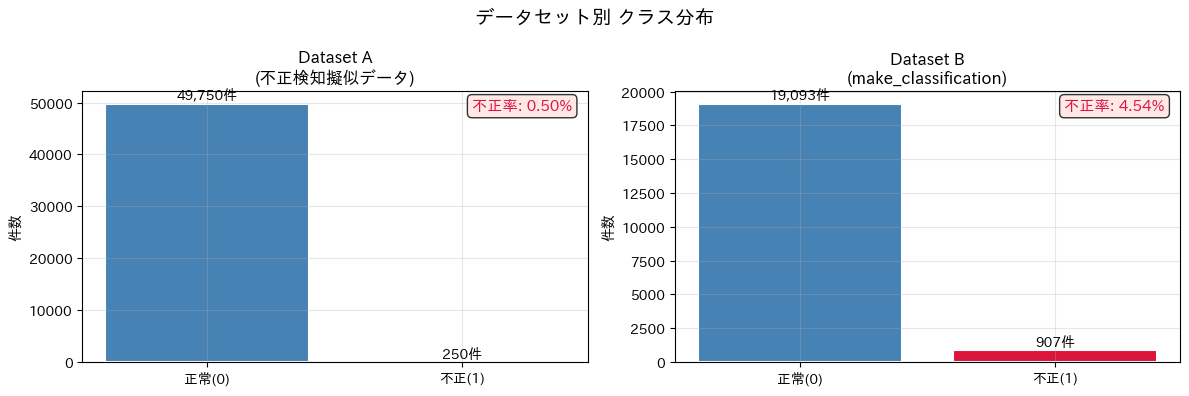

In [3]:
# クラス分布の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_data, title, fraud_rate in zip(
    axes,
    [np.concatenate([y_train_A, y_test_A]),
     np.concatenate([y_train_B, y_test_B])],
    ["Dataset A\n(不正検知擬似データ)", "Dataset B\n(make_classification)"],
    [0.005, 0.03]
):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(["正常(0)", "不正(1)"], counts.values,
                  color=["steelblue", "crimson"], edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{val:,}件", ha="center", va="bottom", fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("件数")
    ax.text(0.97, 0.97, f"不正率: {y_data.mean():.2%}",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=11, color="crimson",
            bbox=dict(boxstyle="round", facecolor="mistyrose", alpha=0.8))

plt.suptitle("データセット別 クラス分布", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "imbalance_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

--- 
## Step2 : 各手法の実装過程と動作確認

各手法がどうデータを変形するかを可視化します。

In [6]:
# 全手法を Dataset B に適用して結果を取得
all_strategies = ImbalanceStrategyFactory.create_all(
    sampling_strategy=0.1, k_neighbors=5, random_state=RANDOM_SEED
)

resampling_results = []
for s in all_strategies:
    result = s.apply(X_train_B, y_train_B)
    resampling_results.append(result)
    print(result.summary(), "\n")

  戦略          : NoResampling（補正なし）
  補正前        : 多数=15,274  少数=726  (少数率=4.537%)
  補正後        : 多数=15,274  少数=726  (少数率=4.537%)
  不均衡比率    : 21.0:1 → 21.0:1 

  戦略          : RandomOverSampling（ランダム複製）
  補正前        : 多数=15,274  少数=726  (少数率=4.537%)
  補正後        : 多数=15,274  少数=1,527  (少数率=9.089%)
  不均衡比率    : 21.0:1 → 10.0:1
  パラメータ    : {'sampling_strategy': 0.1} 

  戦略          : RandomUnderSampling (ランダム削除)
  補正前        : 多数=15,274  少数=726  (少数率=4.537%)
  補正後        : 多数=7,260  少数=726  (少数率=9.091%)
  不均衡比率    : 21.0:1 → 10.0:1
  パラメータ    : {'sampling_strategy': 0.1} 

  戦略          : SMOTE (合成少数サンプル生成)
  補正前        : 多数=15,274  少数=726  (少数率=4.537%)
  補正後        : 多数=15,274  少数=1,527  (少数率=9.089%)
  不均衡比率    : 21.0:1 → 10.0:1
  パラメータ    : {'sampling_strategy': 0.1, 'k_neighbors': 5, 'n_synthetic_generated': 801} 

  戦略          : ADASYN (適応的合成サンプリング)
  補正前        : 多数=15,274  少数=726  (少数率=4.537%)
  補正後        : 多数=15,274  少数=1,527  (少数率=9.089%)
  不均衡比率    : 21.0:1 → 10.0:1
  パラメータ  

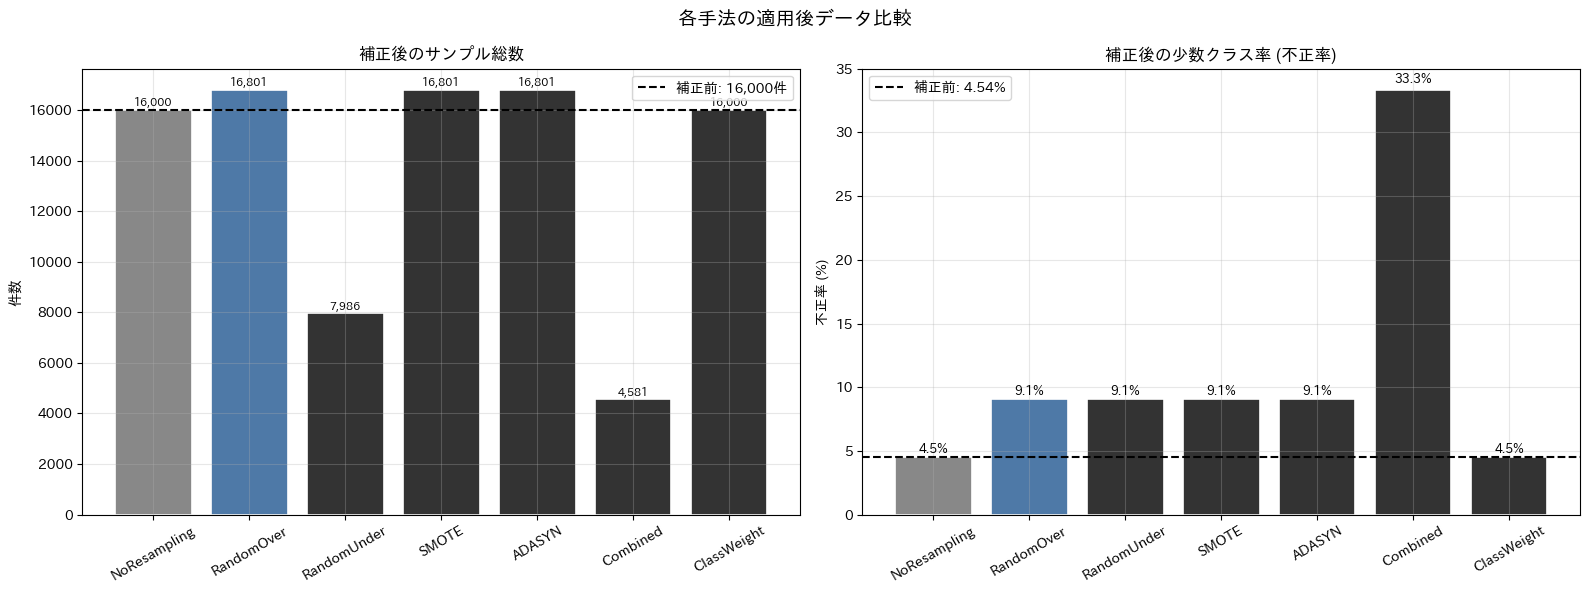

In [7]:
# サンプル数の変化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = [r.strategy_name for r in resampling_results]
short_names = [
    'NoResampling', 'RandomOver', 'RandomUnder',
    'SMOTE', 'ADASYN', 'Combined', 'ClassWeight'
]
colors = [STRATEGY_COLORS.get(n, '#333333') for n in names]

# 左: サンプル総数
totals_before = resampling_results[0].n_before_majority + resampling_results[0].n_before_minority
totals_after = [
    r.n_after_majority + r.n_after_minority for r in resampling_results
]
bars = axes[0].bar(short_names, totals_after, color=colors, edgecolor="white", linewidth=1.2)
axes[0].axhline(totals_before, color="black", linestyle="--", lw=1.5, label=f"補正前: {totals_before:,}件")
axes[0].set_title("補正後のサンプル総数", fontsize=12, fontweight="bold")
axes[0].set_ylabel("件数")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()
for bar, val in zip(bars, totals_after):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.005,
                 f"{val:,}", ha="center", va="bottom", fontsize=8)

# 右: 少数クラス率
rates_after = [r.minority_rate_after * 100 for r in resampling_results]
bars2 = axes[1].bar(short_names, rates_after, color=colors, edgecolor="white", linewidth=1.2)
axes[1].axhline(resampling_results[0].minority_rate_before * 100,
                color="black", linestyle="--", lw=1.5,
                label=f"補正前: {resampling_results[0].minority_rate_before:.2%}")
axes[1].set_title("補正後の少数クラス率 (不正率)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("不正率 (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()
for bar, val in zip(bars2, rates_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

plt.suptitle("各手法の適用後データ比較", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "imbalance_resampling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

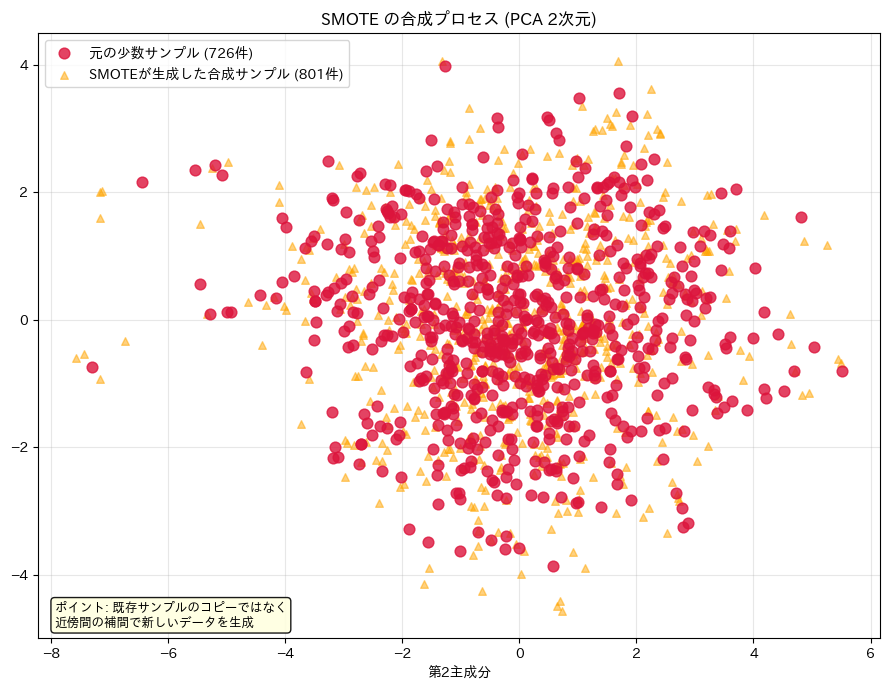

In [8]:
# SMOTEの「合成プロセス」を2次元で可視化
# 理解のため、主成分2次元に圧縮して補間の様子を確認する
from sklearn.decomposition import PCA

# 少数クラスのみ抽出
minority_mask = y_train_B == 1
X_min_2d = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_train_B[minority_mask])

# SMOTE適用後の少数クラスを同じPCA空間に射影
smote_result = ImbalanceStrategyFactory.create("smote", sampling_strategy=0.1).apply(X_train_B, y_train_B)
pca = PCA(n_components=2, random_state=RANDOM_SEED).fit(X_train_B[minority_mask])
# オリジナルと合成を分けて取得
n_original_min = minority_mask.sum()
X_after_min = smote_result.X_resampled[smote_result.y_resampled == 1]
X_original_2d = pca.transform(X_after_min[:n_original_min])
X_synthetic_2d = pca.transform(X_after_min[n_original_min:])

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(
    X_original_2d[:, 0], X_original_2d[:, 1],
    c="crimson", s=60, alpha=0.8, zorder=3, label=f"元の少数サンプル ({n_original_min}件)"
)
ax.scatter(
    X_synthetic_2d[:, 0], X_synthetic_2d[:, 1],
    c="orange", s=30, alpha=0.5, marker="^", zorder=2,
    label=f"SMOTEが生成した合成サンプル ({len(X_synthetic_2d)}件)"
)
ax.set_title("SMOTE の合成プロセス (PCA 2次元)", fontsize=12, fontweight="bold")
ax.set_xlabel("第1主成分")
ax.set_xlabel("第2主成分")
ax.legend(fontsize=10)
ax.text(
    0.02, 0.02, 'ポイント: 既存サンプルのコピーではなく\n近傍間の補間で新しいデータを生成',
    transform=ax.transAxes, fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'smote_synthetic_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

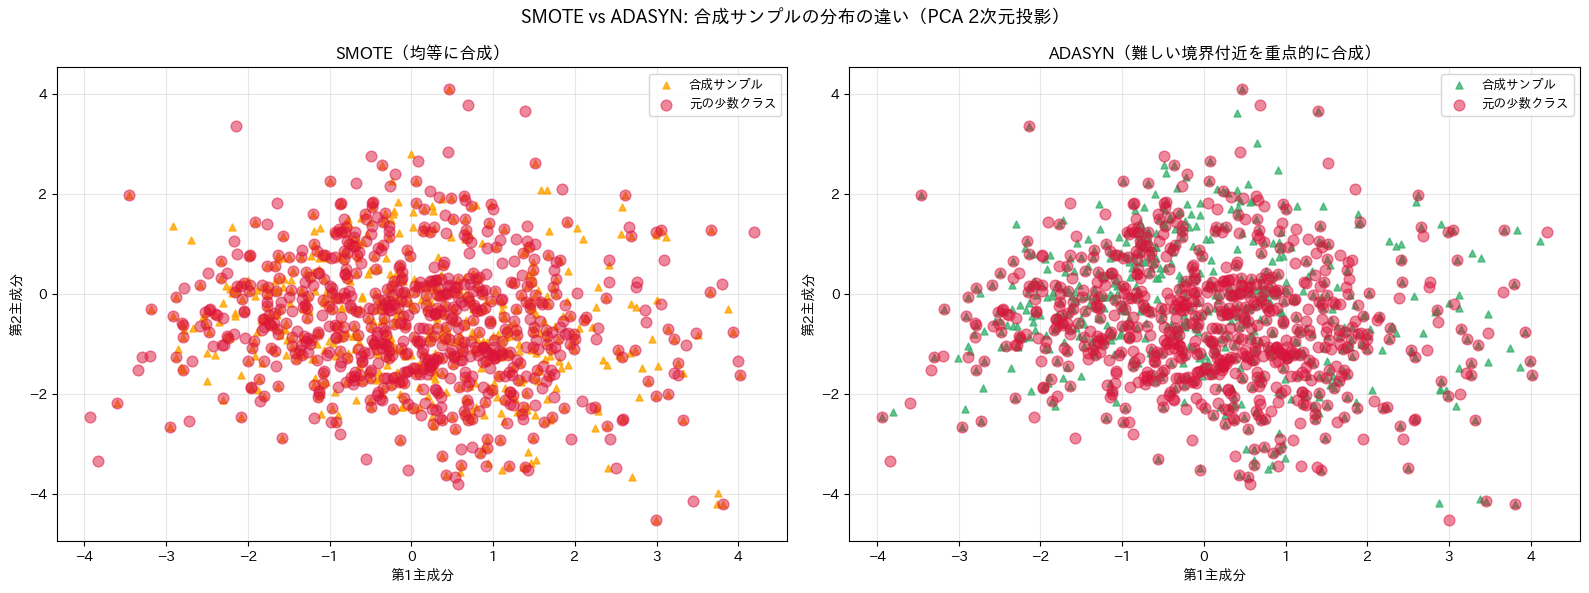

ADASYNは多数クラスと隣接する「難しいサンプル」付近に合成が集中します


In [12]:
# SMOTE vs ADASYN
adasyn_result = ImbalanceStrategyFactory.create('adasyn', sampling_strategy=0.1).apply(X_train_B, y_train_B)

X_smote_min = smote_result.X_resampled[smote_result.y_resampled == 1]
X_adasyn_min = adasyn_result.X_resampled[adasyn_result.y_resampled == 1]

# 全体のPCA空間を作成
pca_all = PCA(n_components=2, random_state=RANDOM_SEED).fit(X_train_B)
X_smote_2d  = pca_all.transform(X_smote_min[n_original_min:])
X_adasyn_2d = pca_all.transform(X_adasyn_min[n_original_min:])
X_orig_2d   = pca_all.transform(X_train_B[minority_mask])
X_maj_2d    = pca_all.transform(X_train_B[~minority_mask])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, X_syn, title, color in zip(
    axes,
    [X_smote_2d, X_adasyn_2d],
    ['SMOTE（均等に合成）', 'ADASYN（難しい境界付近を重点的に合成）'],
    ['orange', 'mediumseagreen']
):
    #ax.scatter(X_maj_2d[:500, 0], X_maj_2d[:500, 1],
    #           c='lightsteelblue', s=10, alpha=0.8, label='多数クラス（正常）')
    ax.scatter(X_syn[:, 0], X_syn[:, 1],
               c=color, s=25, alpha=0.8, marker='^', label='合成サンプル')
    ax.scatter(X_orig_2d[:, 0], X_orig_2d[:, 1],
               c='crimson', s=60, alpha=0.5, zorder=5, label='元の少数クラス')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('第1主成分')
    ax.set_ylabel('第2主成分')
    ax.legend(fontsize=9)

plt.suptitle('SMOTE vs ADASYN: 合成サンプルの分布の違い（PCA 2次元投影）',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'smote_vs_adasyn.png', dpi=150, bbox_inches='tight')
plt.show()
print('ADASYNは多数クラスと隣接する「難しいサンプル」付近に合成が集中します')

---

## Step3 : モデル学習と評価指標の比較

LogisticRegression で各手法を適用し、AUC-ROC / AUC-PR を比較します。

In [17]:
def run_experiment(strategies, X_train, y_train, X_test, y_test, dataset_name='Dataset'):
    """
    全手法を同じ設定で評価するユーティリティ関数。
    Strategyパターンにより、各手法を同じインタフェースで扱える。
    """
    records = []
    for s in strategies:
        # ── Strategy の適用 ──
        result = s.apply(X_train, y_train)
        X_r, y_r = result.X_resampled, result.y_resampled

        # ── モデル構築（ClassWeightのみ重み付きモデル）──
        if s.category == 'algorithm':
            cw = s.compute_weights(y_train)
            clf = LogisticRegression(class_weight=cw, max_iter=500, random_state=RANDOM_SEED)
        else:
            clf = LogisticRegression(max_iter=500, random_state=RANDOM_SEED)

        clf.fit(X_r, y_r)
        y_prob = clf.predict_proba(X_test)[:, 1]

        # 最適閾値でF1を計算
        thresholds = np.arange(0.1, 0.9, 0.02)
        f1s = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
        best_thresh = thresholds[np.argmax(f1s)]
        best_f1 = max(f1s)

        records.append({
            'strategy':        s.name,
            'category':        s.category,
            'auc_roc':         roc_auc_score(y_test, y_prob),
            'auc_pr':          average_precision_score(y_test, y_prob),
            'best_f1':         best_f1,
            'best_threshold':  best_thresh,
            'n_train_after':   len(X_r),
            'minority_rate':   result.minority_rate_after,
            'y_prob':          y_prob,
            'result':          result,
            'clf':             clf,
        })
        #print(f'  [{s.name[:30]:}]  AUC-ROC={records[-1]["auc_roc"]:.4f}'
        #      f'AUC-PR={records[-1]["auc_pr"]:.4f}  F1={best_f1:.4f}')

    return pd.DataFrame([{k: v for k, v in r.items() if k not in ('y_prob', 'result', 'clf')}
                          for r in records]), records


print('\n=== Dataset B で全手法を評価 ===')
all_strategies = ImbalanceStrategyFactory.create_all(
    sampling_strategy=0.1, k_neighbors=5, random_state=RANDOM_SEED
)
df_results_B, records_B = run_experiment(
    all_strategies, X_train_B, y_train_B, X_test_B, y_test_B, 'Dataset B'
)
df_results_B


=== Dataset B で全手法を評価 ===


,strategy,category,auc_roc,auc_pr,best_f1,best_threshold,n_train_after,minority_rate
0,NoResampling（補正なし）,baseline,0.692383,0.381831,0.420635,0.22,16000,0.045375
1,RandomOverSampling（ランダム複製）,oversampling,0.697641,0.367112,0.398340,0.36,16801,0.090887
2,RandomUnderSampling (ランダム削除),undersampling,0.693811,0.377235,0.416058,0.30,7986,0.090909
3,SMOTE (合成少数サンプル生成),oversampling,0.693187,0.378032,0.421818,0.32,16801,0.090887
4,ADASYN (適応的合成サンプリング),oversampling,0.699427,0.370636,0.404494,0.28,16801,0.090887
5,Combined (SMOTE + UnderSampling),combined,0.698676,0.356449,0.391459,0.64,4581,0.333333
6,ClassWeight (クラス重み付け),algorithm,0.701054,0.336418,0.368750,0.72,16000,0.045375


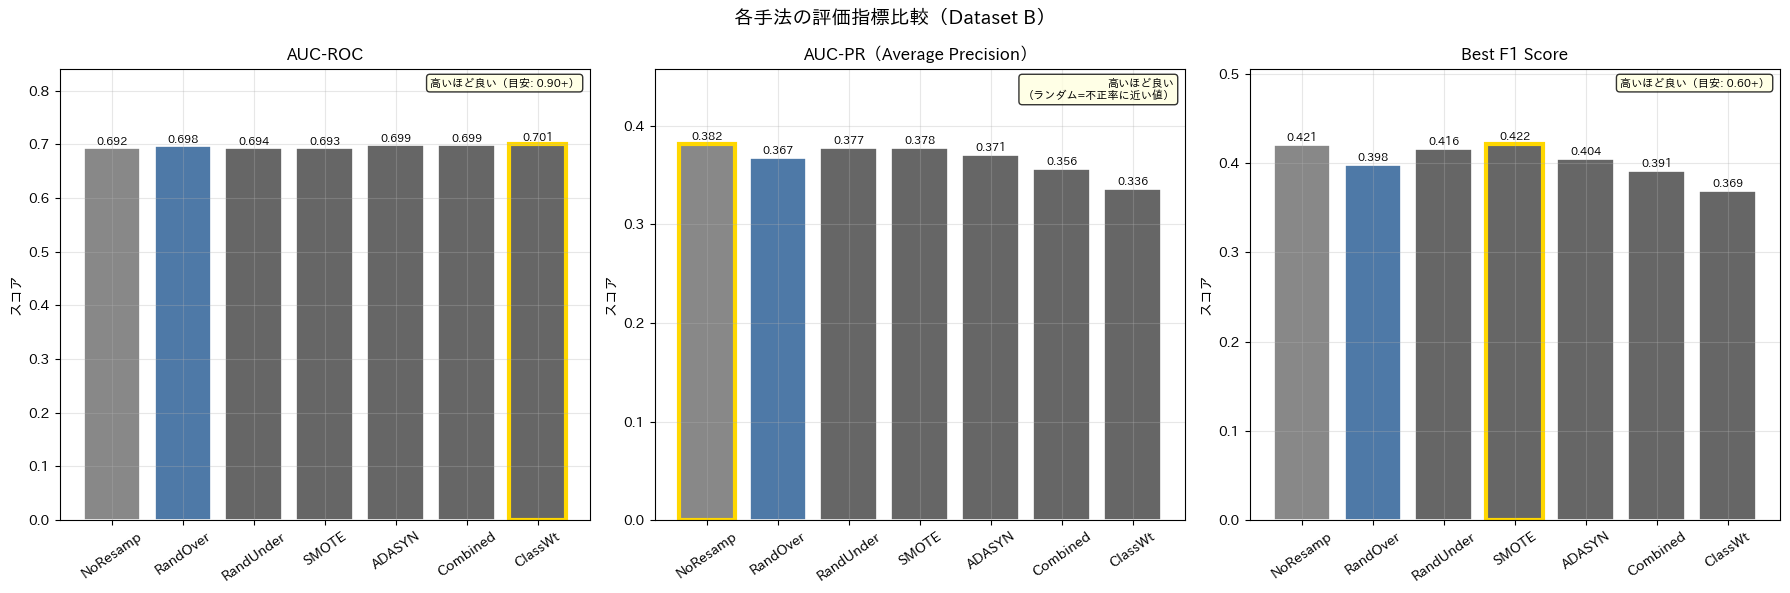

In [18]:
# ── 評価指標の横並びバー比較 ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
short_names = ['NoResamp', 'RandOver', 'RandUnder', 'SMOTE', 'ADASYN', 'Combined', 'ClassWt']
colors = [STRATEGY_COLORS.get(n, '#666') for n in df_results_B['strategy']]

for ax, col, title, baseline_text in zip(
    axes,
    ['auc_roc', 'auc_pr', 'best_f1'],
    ['AUC-ROC', 'AUC-PR（Average Precision）', 'Best F1 Score'],
    ['高いほど良い（目安: 0.90+）', '高いほど良い\n（ランダム=不正率に近い値）', '高いほど良い（目安: 0.60+）']
):
    vals = df_results_B[col].values
    bars = ax.bar(short_names, vals, color=colors, edgecolor='white', linewidth=1.2)
    # 最高値を強調
    best_idx = vals.argmax()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('スコア')
    ax.tick_params(axis='x', rotation=35)
    ax.set_ylim(0, min(vals.max() * 1.20, 1.0))
    ax.text(0.98, 0.98, baseline_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('各手法の評価指標比較（Dataset B）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'imbalance_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

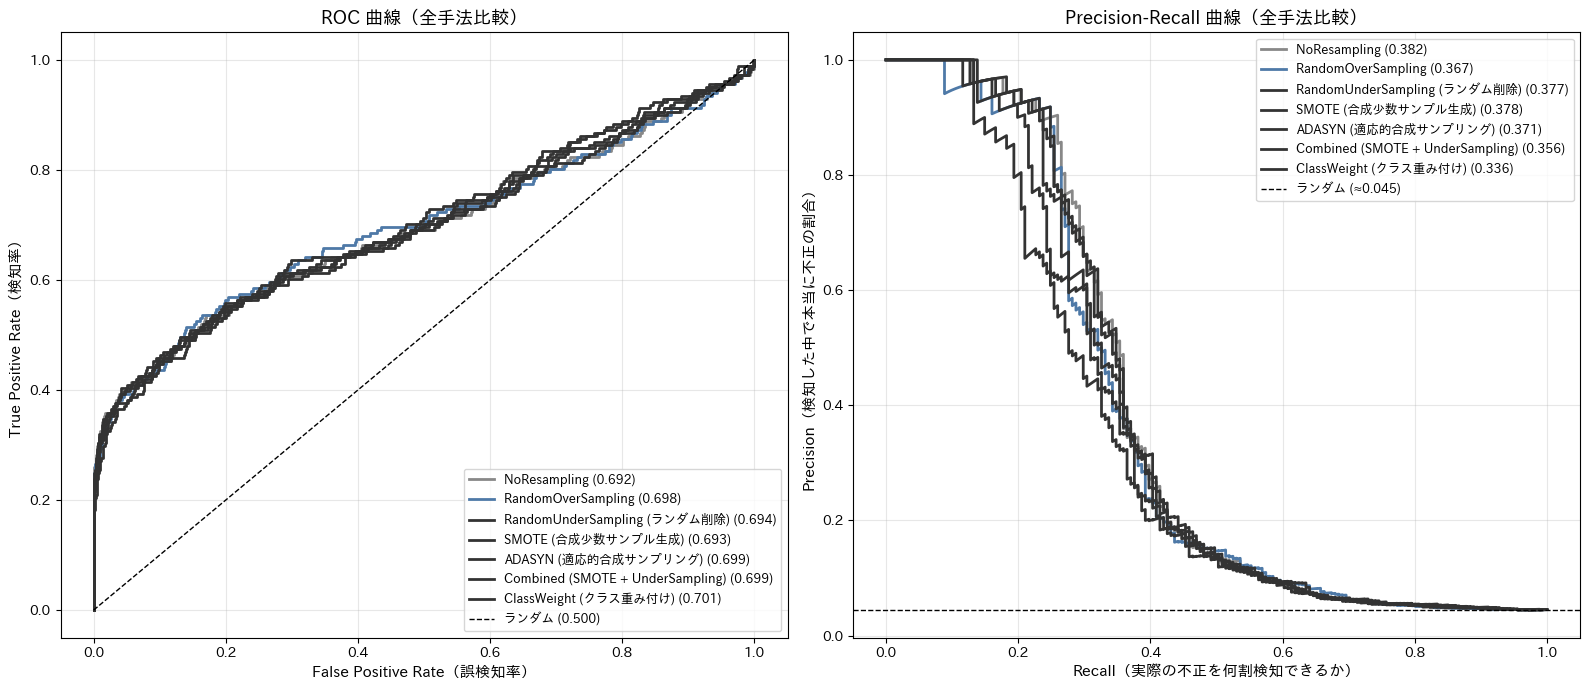

In [19]:
# ── ROC曲線とPR曲線を全手法で重ねてプロット ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for rec in records_B:
    color = STRATEGY_COLORS.get(rec['strategy'], '#333')
    y_prob = rec['y_prob']
    label  = rec['strategy'].split('（')[0]  # 短縮名

    # ROC
    fpr, tpr, _ = roc_curve(y_test_B, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{label} ({rec['auc_roc']:.3f})")

    # PR
    prec, recall, _ = precision_recall_curve(y_test_B, y_prob)
    axes[1].plot(recall, prec, color=color, lw=2,
                 label=f"{label} ({rec['auc_pr']:.3f})")

# ROC 装飾
axes[0].plot([0,1],[0,1],'k--',lw=1, label='ランダム (0.500)')
axes[0].set_xlabel('False Positive Rate（誤検知率）', fontsize=11)
axes[0].set_ylabel('True Positive Rate（検知率）', fontsize=11)
axes[0].set_title('ROC 曲線（全手法比較）', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')

# PR 装飾
baseline = y_test_B.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1,
                label=f'ランダム (≈{baseline:.3f})')
axes[1].set_xlabel('Recall（実際の不正を何割検知できるか）', fontsize=11)
axes[1].set_ylabel('Precision（検知した中で本当に不正の割合）', fontsize=11)
axes[1].set_title('Precision-Recall 曲線（全手法比較）', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'imbalance_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step4 : 手法ごとの特性を深掘り

### 4-1. 閾値チューニングのトレードオフ比較（Precision vs Recall）

In [26]:
for rec in records_B:
    print(rec["strategy"])

NoResampling（補正なし）
RandomOverSampling（ランダム複製）
RandomUnderSampling (ランダム削除)
SMOTE (合成少数サンプル生成)
ADASYN (適応的合成サンプリング)
Combined (SMOTE + UnderSampling)
ClassWeight (クラス重み付け)


NoResampling（補正なし）
SMOTE (合成少数サンプル生成)
Combined (SMOTE + UnderSampling)
ClassWeight (クラス重み付け)


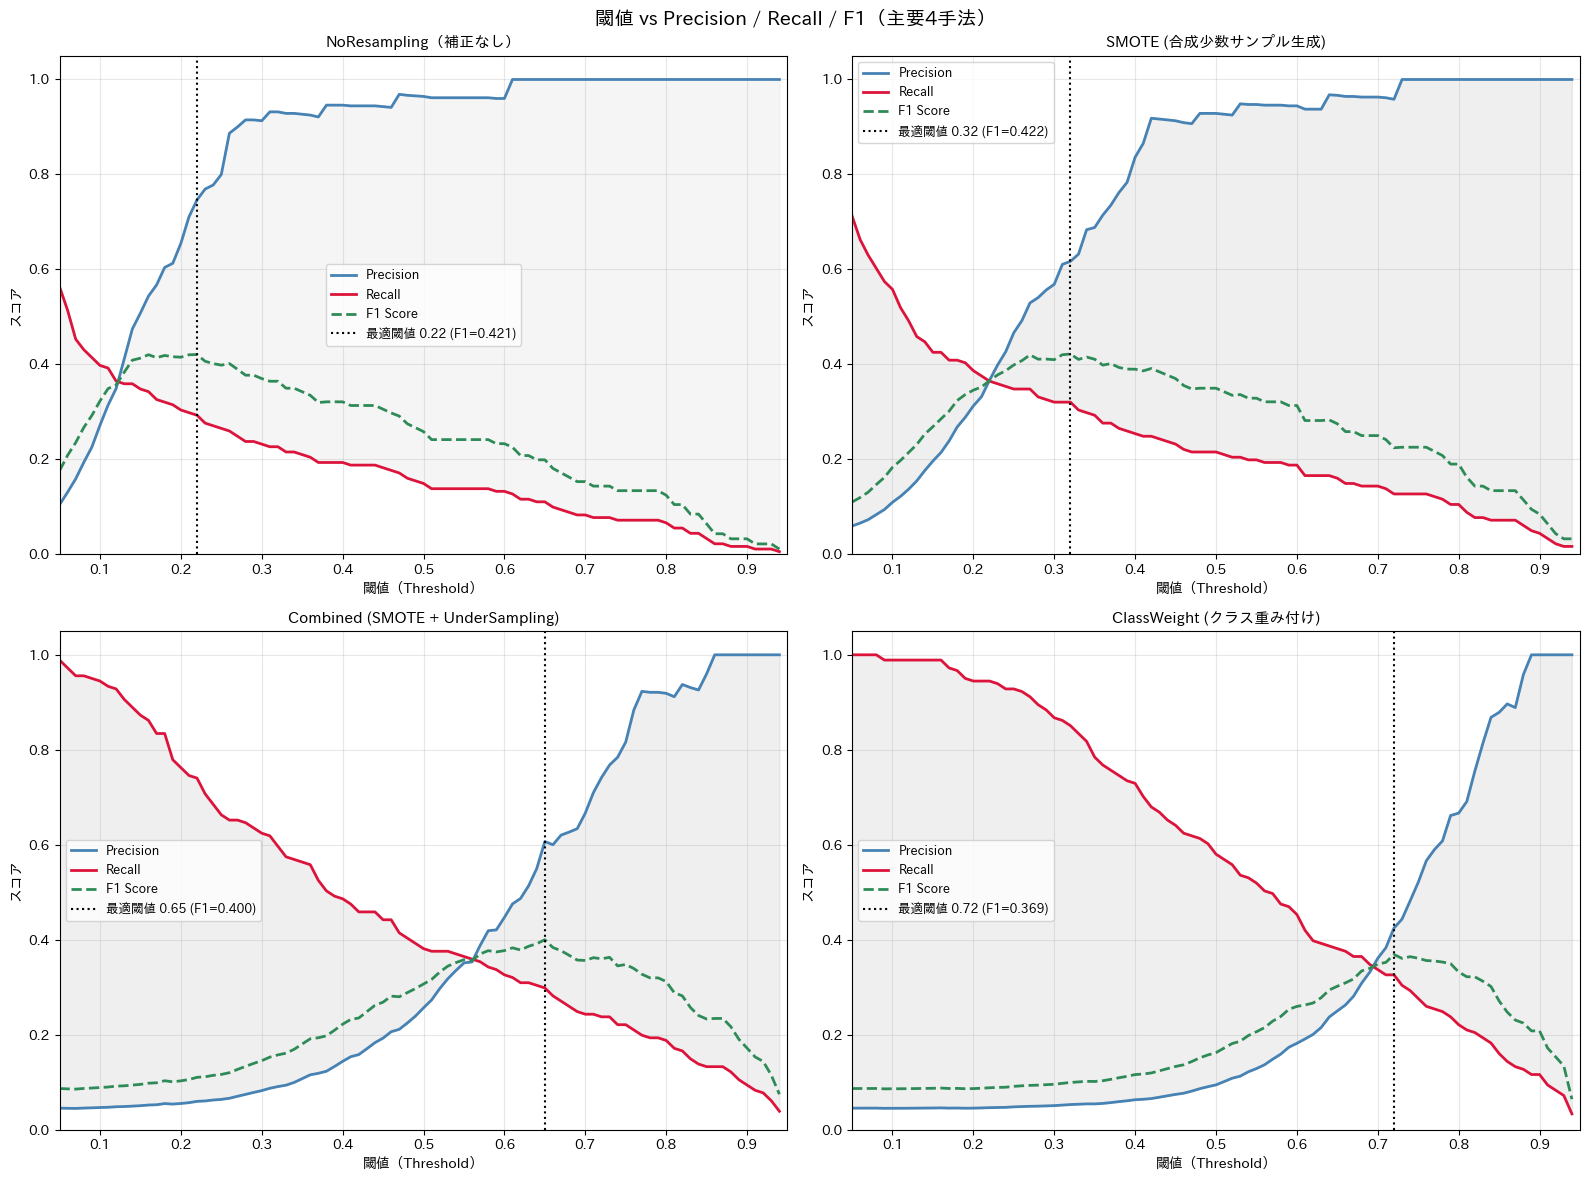

In [27]:
# 主要4手法の閾値 vs Precision/Recall カーブ
from sklearn.metrics import precision_score, recall_score

focus_strategies = ['NoResampling（補正なし）', 'SMOTE (合成少数サンプル生成)',
                    'Combined (SMOTE + UnderSampling)', 'ClassWeight (クラス重み付け)']
focus_records = [r for r in records_B if r['strategy'] in focus_strategies]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
thresholds = np.arange(0.05, 0.95, 0.01)

for ax, rec in zip(axes, focus_records):
    print(rec["strategy"])
    y_prob = rec['y_prob']
    prec_list, rec_list, f1_list = [], [], []
    for t in thresholds:
        y_p = (y_prob >= t).astype(int)
        prec_list.append(precision_score(y_test_B, y_p, zero_division=0))
        rec_list.append(recall_score(y_test_B, y_p, zero_division=0))
        f1_list.append(f1_score(y_test_B, y_p, zero_division=0))

    best_t = thresholds[np.argmax(f1_list)]
    color = STRATEGY_COLORS.get(rec['strategy'], '#333')

    ax.plot(thresholds, prec_list, lw=2, color='steelblue', label='Precision')
    ax.plot(thresholds, rec_list,  lw=2, color='crimson',   label='Recall')
    ax.plot(thresholds, f1_list,   lw=2, color='seagreen',  label='F1 Score', linestyle='--')
    ax.axvline(best_t, color='black', linestyle=':', lw=1.5,
               label=f'最適閾値 {best_t:.2f} (F1={max(f1_list):.3f})')
    ax.fill_between(thresholds, prec_list, rec_list, alpha=0.08, color=color)

    ax.set_title(rec['strategy'], fontsize=11, fontweight='bold')
    ax.set_xlabel('閾値（Threshold）')
    ax.set_ylabel('スコア')
    ax.set_xlim([0.05, 0.95])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=9)

plt.suptitle('閾値 vs Precision / Recall / F1（主要4手法）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'imbalance_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

### 4-2. sampling_strategy パラメータの影響調査

> 「どのくらい補正すれば最も性能が出るか」を実験で確認します。

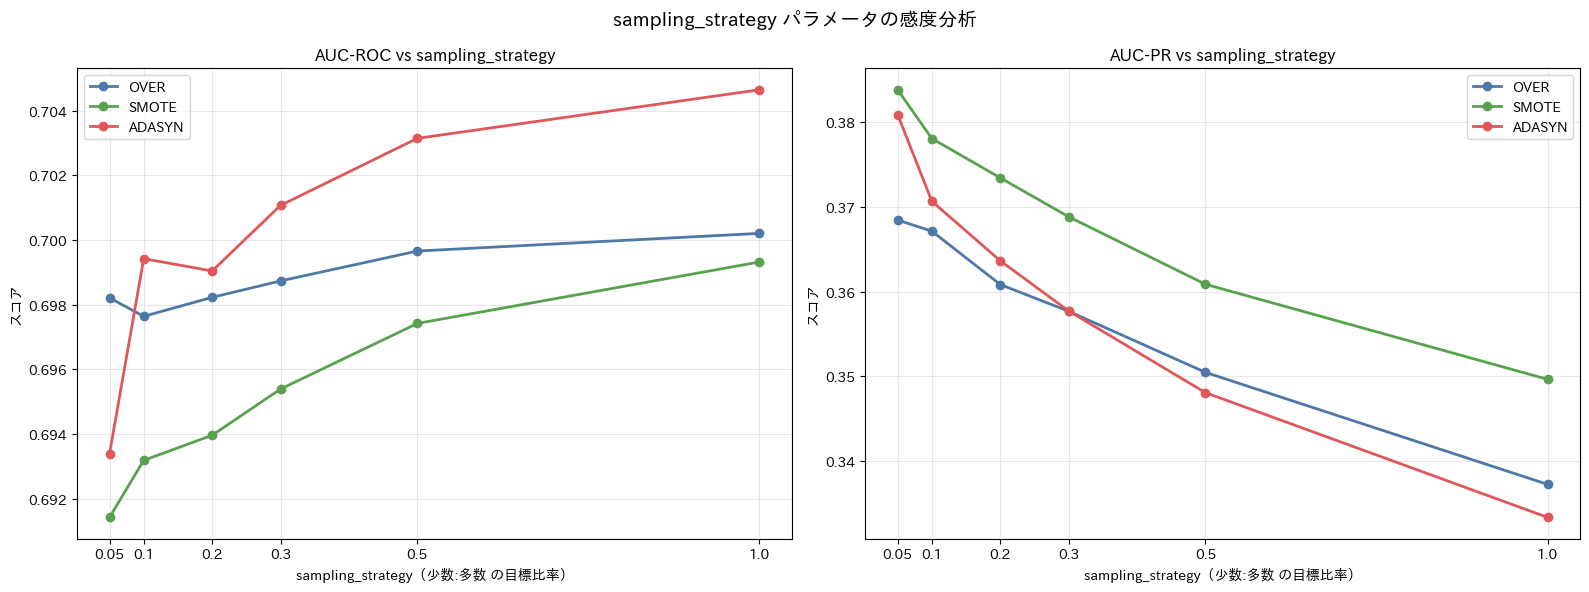

最適な sampling_strategy はデータによって異なります。交差検証での探索が推奨です。


In [35]:
# SMOTE の sampling_strategy を変えてAUC-PRがどう変化するか
strategies_to_compare = ['over', 'smote', 'adasyn']
sampling_rates = [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for strat_key, color in zip(strategies_to_compare,
                            ['#4E79A7', '#59A14F', '#E15759']):
    auc_rocs, auc_prs = [], []
    for sr in sampling_rates:
        #try:
        if strat_key == "over":
            s = ImbalanceStrategyFactory.create(strat_key, sampling_strategy=sr)
        else:
            s = ImbalanceStrategyFactory.create(strat_key, sampling_strategy=sr, k_neighbors=5)
        result = s.apply(X_train_B, y_train_B)
        clf = LogisticRegression(max_iter=500, random_state=RANDOM_SEED)
        clf.fit(result.X_resampled, result.y_resampled)
        prob = clf.predict_proba(X_test_B)[:, 1]
        auc_rocs.append(roc_auc_score(y_test_B, prob))
        auc_prs.append(average_precision_score(y_test_B, prob))
        # except Exception:
        #     auc_rocs.append(np.nan)
        #     auc_prs.append(np.nan)

    axes[0].plot(sampling_rates, auc_rocs, marker='o', color=color,
                 lw=2, label=strat_key.upper())
    axes[1].plot(sampling_rates, auc_prs,  marker='o', color=color,
                 lw=2, label=strat_key.upper())

for ax, title in zip(axes, ['AUC-ROC vs sampling_strategy', 'AUC-PR vs sampling_strategy']):
    ax.set_xlabel('sampling_strategy（少数:多数 の目標比率）')
    ax.set_ylabel('スコア')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_xticks(sampling_rates)
    ax.set_xticklabels([f'{r}' for r in sampling_rates])

plt.suptitle('sampling_strategy パラメータの感度分析', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'imbalance_param_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('最適な sampling_strategy はデータによって異なります。交差検証での探索が推奨です。')

--- 

## Step5 : 総合結果サマリー

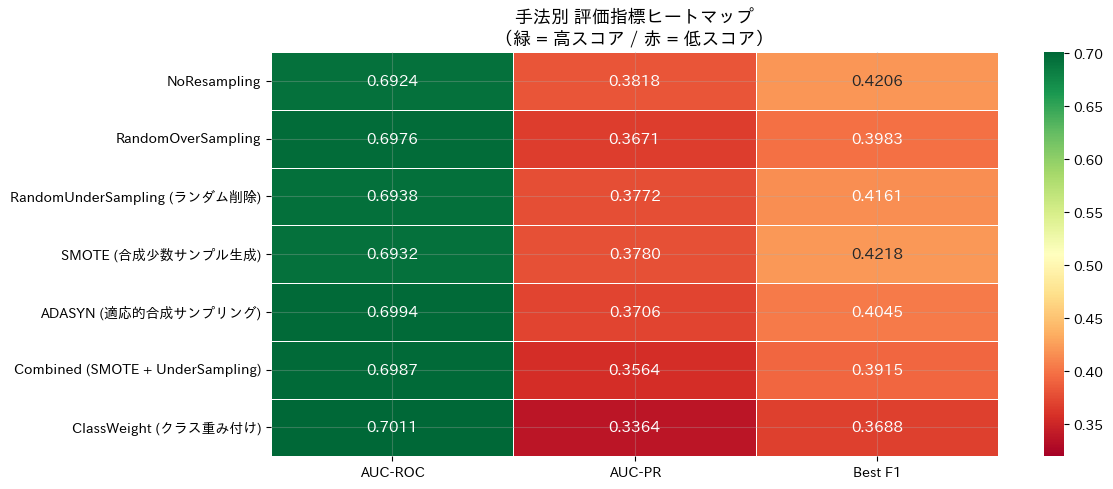


                                   AUC-ROC    AUC-PR   Best F1  補正後サンプル数    補正後不正率
手法                                                                                
NoResampling                      0.692383  0.381831  0.420635     16000  0.045375
RandomOverSampling                0.697641  0.367112  0.398340     16801  0.090887
RandomUnderSampling (ランダム削除)      0.693811  0.377235  0.416058      7986  0.090909
SMOTE (合成少数サンプル生成)                0.693187  0.378032  0.421818     16801  0.090887
ADASYN (適応的合成サンプリング)              0.699427  0.370636  0.404494     16801  0.090887
Combined (SMOTE + UnderSampling)  0.698676  0.356449  0.391459      4581  0.333333
ClassWeight (クラス重み付け)             0.701054  0.336418  0.368750     16000  0.045375


In [36]:
# ── ヒートマップで一覧 ──
summary_df = df_results_B[['strategy', 'auc_roc', 'auc_pr', 'best_f1',
                            'n_train_after', 'minority_rate']].copy()
summary_df['strategy'] = summary_df['strategy'].str.split('（').str[0]
summary_df.columns = ['手法', 'AUC-ROC', 'AUC-PR', 'Best F1',
                       '補正後サンプル数', '補正後不正率']
summary_df = summary_df.set_index('手法')

fig, ax = plt.subplots(figsize=(12, 5))
numeric_cols = ['AUC-ROC', 'AUC-PR', 'Best F1']
heatmap_data = summary_df[numeric_cols].astype(float)

sns.heatmap(
    heatmap_data, annot=True, fmt='.4f',
    cmap='RdYlGn', ax=ax,
    linewidths=0.5, linecolor='white',
    vmin=heatmap_data.values.min() * 0.95,
    vmax=heatmap_data.values.max(),
    annot_kws={'size': 11}
)
ax.set_title('手法別 評価指標ヒートマップ\n（緑 = 高スコア / 赤 = 低スコア）',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'imbalance_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(summary_df.to_string())

In [37]:
# ── 手法選択の判断基準まとめ ──
print('=' * 65)
print('手法選択のガイドライン（実務向け）')
print('=' * 65)

guidelines = [
    ('NoResampling',     'まず必ずここからスタート。基準値として必ず計測する'),
    ('RandomOver',       'データが少ないとき・速度優先のプロトタイプで使う'),
    ('RandomUnder',      'データが大量にあり高速化したいとき。情報損失に注意'),
    ('SMOTE',            '最もよく使われる定番。不均衡率が高い場合に特に有効'),
    ('ADASYN',           '境界が複雑・難しいサンプルが多いときにSMOTEより有効'),
    ('Combined',         'データが大量で計算資源に余裕があるとき。最も安定'),
    ('ClassWeight',      'データを変形せず済む。モデルが class_weight を支持している場合'),
]

for name, guide in guidelines:
    print(f'  {name:18s}: {guide}')

print()
print('【共通の注意点】')
print('  1. SMOTE/ADASYN は必ずTrainデータのみに適用する（DataLeak防止）')
print('  2. sampling_strategy は交差検証で探索するのがベスト')
print('  3. 評価は必ずAUC-ROCとAUC-PRの両方で確認する')
print('  4. 最終的な閾値はビジネスコスト（見逃し損失 vs 誤検知コスト）で決める')

手法選択のガイドライン（実務向け）
  NoResampling      : まず必ずここからスタート。基準値として必ず計測する
  RandomOver        : データが少ないとき・速度優先のプロトタイプで使う
  RandomUnder       : データが大量にあり高速化したいとき。情報損失に注意
  SMOTE             : 最もよく使われる定番。不均衡率が高い場合に特に有効
  ADASYN            : 境界が複雑・難しいサンプルが多いときにSMOTEより有効
  Combined          : データが大量で計算資源に余裕があるとき。最も安定
  ClassWeight       : データを変形せず済む。モデルが class_weight を支持している場合

【共通の注意点】
  1. SMOTE/ADASYN は必ずTrainデータのみに適用する（DataLeak防止）
  2. sampling_strategy は交差検証で探索するのがベスト
  3. 評価は必ずAUC-ROCとAUC-PRの両方で確認する
  4. 最終的な閾値はビジネスコスト（見逃し損失 vs 誤検知コスト）で決める
